<a href="https://colab.research.google.com/github/salmanmfa2/data-science-2026/blob/main/Pertemuan5_Salman_MFA_240401010356.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd, numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')
print(df.isnull().sum())
df.head()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Standardisasi Kolom Survived,Alive, dan Alone menjadi boolean

In [40]:
df['survived'] = df['survived'].map({1: True, 0: False})
df['alive'] = df['alive'].map({'no':False, 'yes':True})
display(df.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,False,False
1,True,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,True,False
2,True,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True,True
3,True,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,True,False
4,False,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,False,True


### Histogram Distribusi Selamat Berdasarkan Usia

#### 1. Apa yang terlihat?
*   **Puncak Keselamatan:** Terdapat lonjakan signifikan jumlah penumpang yang selamat (hijau) pada rentang usia balita (0-5 tahun).
*   **Dominasi Kematian:** Pada rentang usia dewasa produktif (20-40 tahun), jumlah penumpang yang tidak selamat (merah) jauh lebih tinggi dibandingkan yang selamat.
*   **Data Hilang:** Ada banyak data usia yang kosong (NaN) yang tidak terwakili sepenuhnya dalam distribusi ini.

#### 2. Mengapa Penting?
*   **Kebijakan Evakuasi:** Mengonfirmasi adanya prioritas "wanita dan anak-anak" saat proses penyelamatan.
*   **Risiko Usia:** Menunjukkan bahwa usia merupakan faktor krusial dalam menentukan peluang bertahan hidup.

#### 3. Tindak Lanjut?
*   **Imputasi Data:** Mengisi nilai usia yang hilang (missing values) menggunakan median atau rata-rata berdasarkan kategori kelas/gender agar analisis lebih akurat.
*   **Pengelompokan (Binning):** Mengelompokkan usia menjadi kategori (Anak, Remaja, Dewasa, Lansia) untuk penyederhanaan model.

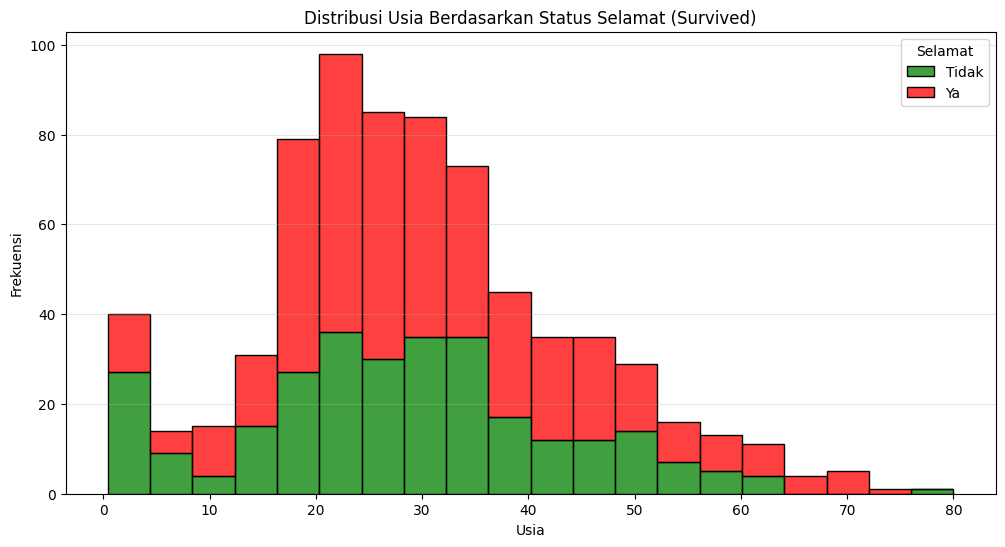

In [41]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='age', hue='survived', multiple='stack', bins=20, palette={True : 'green', False : 'red'})
plt.title('Distribusi Usia Berdasarkan Status Selamat (Survived)')
plt.xlabel('Usia')
plt.ylabel('Frekuensi')
plt.legend(title='Selamat', labels=['Tidak', 'Ya'])
plt.grid(axis='y', alpha=0.3)
plt.show()

### Bar Chart Jumlah Selamat per Kelas Penumpang

#### 1. Apa yang terlihat?
*   **Kontras Keselamatan:** Kelas Pertama memiliki jumlah dan persentase selamat tertinggi (sekitar 63%), sementara Kelas Ketiga memiliki jumlah kematian terbanyak secara absolut.
*   **Kesenjangan Peluang:** Peluang selamat penumpang Kelas Pertama hampir 3 kali lipat lebih besar dibandingkan penumpang Kelas Ketiga (24%).

#### 2. Mengapa Penting?
*   **Pengaruh Status Sosial:** Menunjukkan korelasi linear antara kelas ekonomi dengan akses terhadap fasilitas penyelamatan (sekoci).
*   **Lokasi Kabin:** Menunjukkan kemungkinan bahwa posisi kabin kelas atas yang lebih dekat dengan dek sekoci sangat berpengaruh.

#### 3. Tindak Lanjut?
*   **Analisis Interaksi:** Melihat hubungan antara Kelas dan Gender (misal: apakah pria kelas 1 lebih selamat daripada wanita kelas 3?).
*   **Korelasi Lokasi:** Jika data 'deck' memungkinkan, hubungkan posisi kabin dengan tingkat keselamatan per kelas.

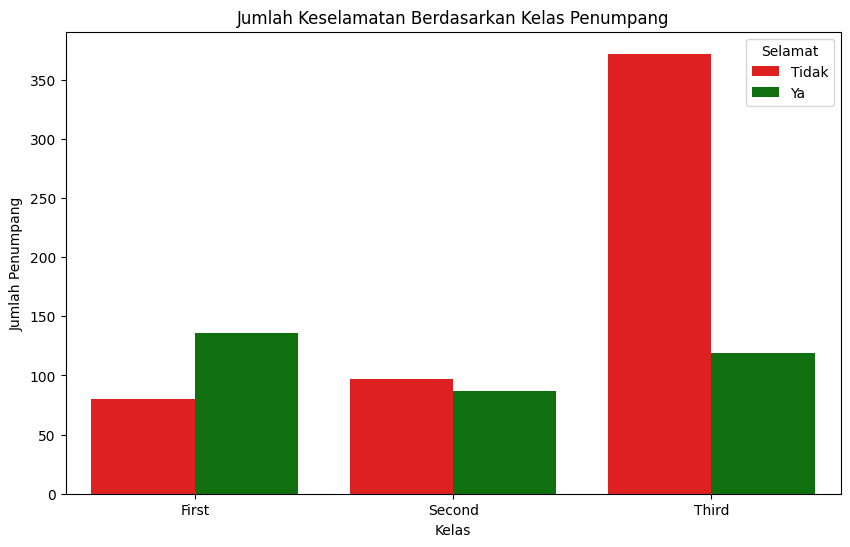

Persentase Keselamatan per Kelas:
class
First     62.962963
Second    47.282609
Third     24.236253
Name: survived, dtype: float64


/tmp/ipykernel_2575/1891749392.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate = df.groupby('class')['survived'].mean() * 100


In [42]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='class', hue='survived', palette={True: 'green', False: 'red'})
plt.title('Jumlah Keselamatan Berdasarkan Kelas Penumpang')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Penumpang')
plt.legend(title='Selamat', labels=['Tidak', 'Ya'])
plt.show()

# Menampilkan persentase keselamatan per kelas untuk data pendukung
survival_rate = df.groupby('class')['survived'].mean() * 100
print("Persentase Keselamatan per Kelas:")
print(survival_rate)

##Scatter Plot

#### 1. Apa yang terlihat?
*   **Distribusi Biaya (Fare):** Penumpang kelas pertama (biru) memiliki variasi biaya yang sangat luas, dengan beberapa 'outliers' yang membayar jauh lebih mahal daripada kelas lainnya. Sebaliknya, kelas kedua (oranye) dan ketiga (hijau) terkumpul di area biaya rendah.
*   **Korelasi Usia dan Keselamatan:** Terlihat bahwa lingkaran (selamat) lebih banyak ditemukan pada usia muda dan anak-anak di semua kelas. Namun, pada kelas ketiga (hijau), simbol 'X' (tidak selamat) mendominasi hampir di seluruh rentang usia.
*   **Pola Kelas:** Terdapat pemisahan visual yang jelas antara kelas penumpang berdasarkan biaya perjalanan, di mana kelas pertama berada di posisi atas grafik (fare tinggi).

#### 2. Mengapa Penting?
*   **Identifikasi Ketimpangan:** Visualisasi ini menunjukkan bahwa status sosial ekonomi (kelas) memiliki hubungan yang sangat kuat dengan biaya yang dibayarkan dan kemungkinan untuk selamat.
*   **Deteksi Outliers:** Kita bisa melihat beberapa penumpang yang membayar sangat mahal (di atas 500) yang mungkin merupakan anomali atau data khusus yang perlu diperhatikan dalam model prediksi.
*   **Validasi Hipotesis:** Mendukung hipotesis bahwa wanita dan anak-anak (yang biasanya berusia muda) serta penumpang kelas atas diprioritaskan saat evakuasi.

#### 3. Tindak Lanjut?
*   **Analisis Outliers:** Melakukan pemeriksaan lebih lanjut pada data 'Fare' yang sangat tinggi untuk melihat apakah ada kesalahan input atau informasi tambahan (misal: rombongan besar).
*   **Feature Engineering:** Mengingat usia dan biaya memiliki pola tertentu, kita bisa membuat fitur baru seperti 'Rich Child' atau kategori usia (Bayi, Anak, Dewasa, Lansia) untuk meningkatkan performa model Machine Learning.
*   **Uji Statistik:** Melakukan uji korelasi formal (seperti korelasi Spearman) antara 'Fare' dan 'Survived' untuk mengukur kekuatan hubungan secara matematis.

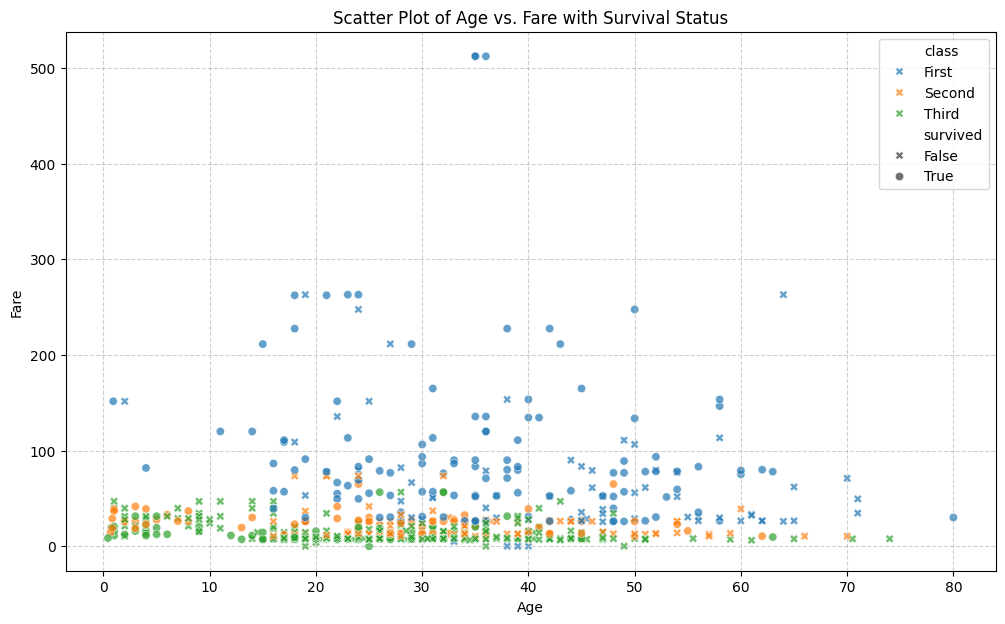

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='age', y='fare', hue='class', style='survived', markers={True: 'o', False: 'X'}, alpha=0.7)
plt.title('Scatter Plot of Age vs. Fare with Survival Status')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Scatter Plots by Passenger Class (Filtered)

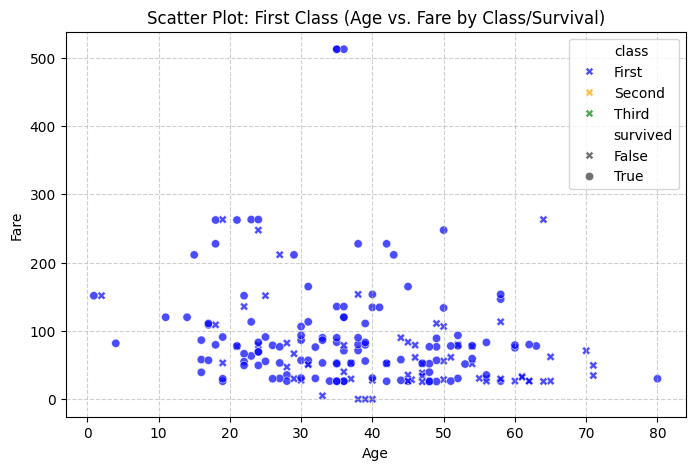

In [44]:
plt.figure(figsize=(8, 5))
df_first_class = df[df['class'] == 'First']
full_palette = {'First': 'blue', 'Second': 'orange', 'Third': 'green'}
sns.scatterplot(data=df_first_class, x='age', y='fare', hue='class', style='survived', markers={True: 'o', False: 'X'}, alpha=0.7, palette=full_palette)
plt.title('Scatter Plot: First Class (Age vs. Fare by Class/Survival)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

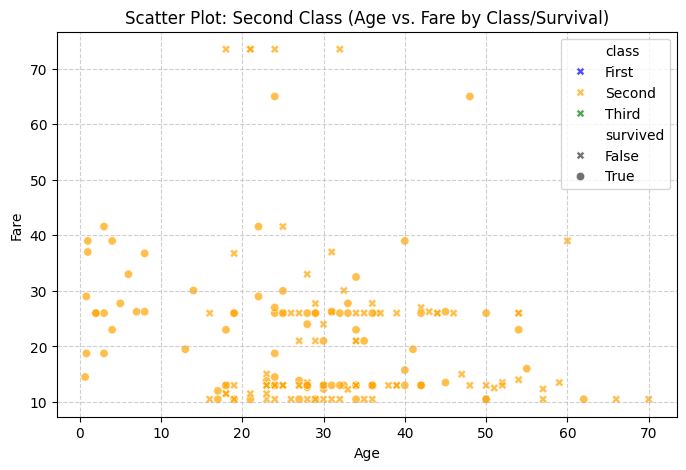

In [45]:
plt.figure(figsize=(8, 5))
df_second_class = df[df['class'] == 'Second']
full_palette = {'First': 'blue', 'Second': 'orange', 'Third': 'green'}
sns.scatterplot(data=df_second_class, x='age', y='fare', hue='class', style='survived', markers={True: 'o', False: 'X'}, alpha=0.7, palette=full_palette)
plt.title('Scatter Plot: Second Class (Age vs. Fare by Class/Survival)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

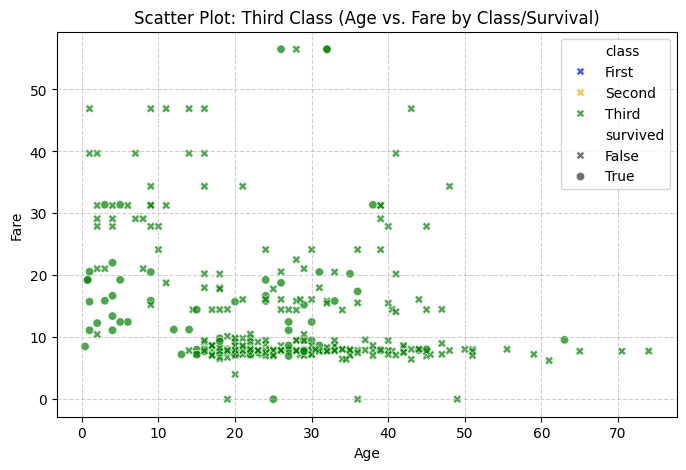

In [46]:
plt.figure(figsize=(8, 5))
df_third_class = df[df['class'] == 'Third']
full_palette = {'First': 'blue', 'Second': 'orange', 'Third': 'green'}
sns.scatterplot(data=df_third_class, x='age', y='fare', hue='class', style='survived', markers={True: 'o', False: 'X'}, alpha=0.7, palette=full_palette)
plt.title('Scatter Plot: Third Class (Age vs. Fare by Class/Survival)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Box Plot: Distribusi Fare berdasarkan Kelas dan Gender

#### 1. Apa yang terlihat?
*   **Variasi Biaya (Fare):** Kelas Pertama menunjukkan rentang harga tiket yang sangat luas dan jauh lebih tinggi dibandingkan kelas lainnya. Banyak terdapat 'outliers' (titik-titik di luar garis) yang menunjukkan penumpang dengan biaya tiket sangat ekstrem.
*   **Perbandingan Gender:** Pada Kelas Pertama, terlihat bahwa median biaya tiket untuk perempuan cenderung sedikit lebih tinggi atau memiliki variasi yang lebih besar dibandingkan laki-laki.
*   **Konsistensi Kelas Bawah:** Harga tiket untuk Kelas Kedua dan Ketiga terlihat sangat rendah dan terkonsentrasi, menunjukkan standarisasi harga yang ketat di kelas ekonomi.

#### 2. Mengapa Penting?
*   **Identifikasi Outliers:** Membantu kita memahami bahwa data 'Fare' tidak terdistribusi secara normal dan memiliki kemiringan (skewness) yang tinggi.
*   **Hubungan Status dan Ekonomi:** Mengonfirmasi secara visual perbedaan daya beli yang sangat kontras antar kelas penumpang.

#### 3. Tindak Lanjut?
*   **Transformasi Data:** Karena adanya outliers yang ekstrem pada kolom Fare, disarankan melakukan transformasi logaritmik atau scaling jika data ini akan digunakan dalam model Machine Learning.
*   **Analisis Lanjutan:** Meneliti apakah penumpang dengan 'Fare' ekstrem memiliki tingkat keselamatan 100%.

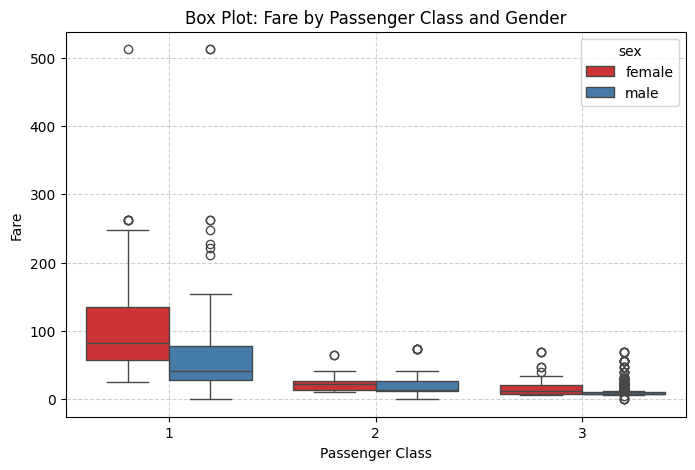

In [50]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='pclass', y='fare', hue='sex', palette='Set1')
plt.title('Box Plot: Fare by Passenger Class and Gender')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.grid(True, linestyle='--', alpha=0.6)



boxplot
